# Predicting Antibacterial Activity Against E. coli Using Molecular Descriptors

### Priscilla Vaskez · Trinity Ho · Yasemin Sucu · Dongwan Kim

## Objective

Predict the antibacterial inhibition rate against E. coli (INHIB_AVE) using a combination of molecular descriptors computed from small-molecule SMILES data (for example: molecular weight, logP, TPSA) and experimental features extracted directly from the CO-ADD dataset (for example: INHIB_STD, NASSAYS, DMAX_AVE, MIC-derived features). Our models learn to predict the continuous inhibition percentage directly from these features. We train and compare three classical ML regression models.

# Basic Data Preview

Read CO-ADD CSV files with pandas and preview the first rows using `head()`.

CO-ADD provides two CSV files because they serve different purposes:
- `InhibitionData` contains single-concentration inhibition results (good for quick screening).
- `DoseResponseData` contains multi-concentration dose-response results (better for detailed potency analysis).

In [49]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pylab
import scipy.stats as stats
import statsmodels.api as sm
import tensorflow as tf
import umap
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, QED, rdMolDescriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from statsmodels.formula.api import ols
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.cluster import KMeans
from pyclustering.utils.metric import * 
from nltk.cluster.kmeans import KMeansClusterer

---
This sets the folder and file paths for the two CO-ADD CSV files.
- `DATA_DIR` points to the folder containing the data.
- `INHIB_PATH` and `DOSE_PATH` build the full path to each CSV file using `Path` / operator.

In [2]:
DATA_DIR = Path("CO-ADD_r03.02-2020_CSV")
INHIB_PATH = DATA_DIR / "CO-ADD_InhibitionData_r03_01-02-2020_CSV.csv"
DOSE_PATH = DATA_DIR / "CO-ADD_DoseResponseData_r03_01-02-2020_CSV.csv"

---

## Open Inhibition data CSV file

In [3]:
# There are two CSV files in the CO-ADD folder.
# For now, we will open the InhibitionData file.

df = pd.read_csv(INHIB_PATH, low_memory=False)
print(df.head())

   Unnamed: 0        COADD_ID  COMPOUND_CODE COMPOUND_NAME     PROJECT_ID  \
0           0  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
1           1  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
2           2  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
3           3  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   
4           4  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   

                          LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  Russian Academy of Science (Russia)   GN_046         Escherichia coli   
1  Russian Academy of Science (Russia)   GN_049         Escherichia coli   
2  Russian Academy of Science (Russia)   GP_020    Staphylococcus aureus   
3  Russian Academy of Science (Russia)   FG_001         Candida albicans   
4  Russian Academy of Science (Russia)   FG_002  Cryptococcus neoformans   

             STRAIN  NASSAYS  INHIB_AVE  INHIB_STD      CONC  \
0      lpxC; MB4

---
## Open the other CO-ADD file (DoseResponseData)

In [4]:
# Open the other CO-ADD file (DoseResponseData)
df2 = pd.read_csv(DOSE_PATH, low_memory=False)
print(df2.head())

   Unnamed: 0        COADD_ID COMPOUND_CODE COMPOUND_NAME  \
0           0  CO-ADD:0136135    0367428:01           NaN   
1           1  CO-ADD:0136135    0367428:01           NaN   
2           2  CO-ADD:0136135    0367428:01           NaN   
3           3  CO-ADD:0136135    0367428:01           NaN   
4           4  CO-ADD:0136135    0367428:01           NaN   

                                   SMILES     PROJECT_ID  \
0  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
1  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
2  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
3  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
4  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   

                      LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  NIH/NCI (USA) - Diversity Set V   MA_007             Homo sapiens   
1  NIH/NCI (USA) - Diversity Set V   GP_020    Staphylococcus aureus   
2  NIH/NCI (USA) - Diversity Set V   GN_042   Pseudomona

---
The below cell reads the two CO-ADD CSV files into pandas DataFrames and prints basic information about them.
- `shape` shows the number of rows and columns in each file.
- `columns.tolist()` lists the column names so you can see what data fields are available.
This helps verify the files loaded correctly and shows what information each dataset contains.

In [5]:
df_inhib = pd.read_csv(INHIB_PATH, low_memory=False)
df_dose = pd.read_csv(DOSE_PATH, low_memory=False)

print("InhibitionData shape:", df_inhib.shape)
print("DoseResponseData shape:", df_dose.shape)

print("\nInhibitionData columns:")
print(df_inhib.columns.tolist())

print("\nDoseResponseData columns:")
print(df_dose.columns.tolist())

InhibitionData shape: (802918, 14)
DoseResponseData shape: (42209, 15)

InhibitionData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES']

DoseResponseData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'SMILES', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


In [6]:
ORGANISM_COL = "ORGANISM"
ECOLI_NAME = "Escherichia coli"
EXACT_KEYS = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Find E. coli rows in inhibition data
mask_inhib = df_inhib[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

# Find E. coli rows in dose-response data
mask_dose = df_dose[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

ecoli_inhib = df_inhib.loc[mask_inhib].copy()
ecoli_dose = df_dose.loc[mask_dose].copy()

# Diagnostic counts: compound-level overlap and exact experiment-level overlap.
overlap_ids = set(ecoli_inhib["COADD_ID"]).intersection(ecoli_dose["COADD_ID"])
inhib_exact_keys = set(map(tuple, ecoli_inhib[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
dose_exact_keys = set(map(tuple, ecoli_dose[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
overlap_exact_keys = inhib_exact_keys.intersection(dose_exact_keys)

print(f"E. coli inhibition rows: {len(ecoli_inhib):,}")
print(f"E. coli dose-response rows: {len(ecoli_dose):,}")
print(f"Overlapping COADD_ID values: {len(overlap_ids):,}")
print(f"Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): {len(overlap_exact_keys):,}")
print(f"Unique E. coli inhibition strains: {ecoli_inhib['STRAIN'].nunique()}")
print(f"Unique E. coli dose-response strains: {ecoli_dose['STRAIN'].nunique()}")

E. coli inhibition rows: 237,752
E. coli dose-response rows: 4,711
Overlapping COADD_ID values: 4,174
Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): 4,268
Unique E. coli inhibition strains: 3
Unique E. coli dose-response strains: 4


---
We will use all the strains of E. coli for this project. This means we are not excluding any specific E. coli variant from the initial analysis, so the data will reflect the full diversity of E. coli strains present in the CO-ADD datasets. This helps us get a broad view of how E. coli responds overall before we decide whether to compare individual strains later.

---
## Create a simple merged E. coli DataFrame

We match the two CSV files using `COADD_ID`, `STRAIN`, and `ASSAY_ID` so the inhibition and dose-response values come from the same E. coli experiment. This gives us 4268 exact-matched rows across 4174 unique compounds while keeping the existing columns and only adding the non-overlapping columns from the dose-response file.


In [7]:
# Use COADD_ID + STRAIN + ASSAY_ID so the rows refer to the same exact experiment.
exact_keys = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Remove rows missing the merge keys or SMILES, and keep one row per exact match key.
def keep_exact_rows(df):
    return (
        df
        .dropna(subset=exact_keys + ["SMILES"])
        .drop_duplicates(subset=exact_keys)
        .reset_index(drop=True)
    )

ecoli_inhib_exact = keep_exact_rows(ecoli_inhib)
ecoli_dose_exact = keep_exact_rows(ecoli_dose)

# Find the columns that appear only in the dose-response table.
# The exact match keys are excluded because they are already used for the merge.
dose_only_cols = [
    col for col in ecoli_dose_exact.columns
    if col not in ecoli_inhib_exact.columns and col not in exact_keys
]

# Merge the two cleaned tables into one exact-match DataFrame.
# Keep all columns from the inhibition table and add only new columns from the dose-response table.
ecoli_merged_df = pd.merge(
    ecoli_inhib_exact,
    ecoli_dose_exact[exact_keys + dose_only_cols],
    on=exact_keys,
    how="inner"
)
ecoli_merged_df = ecoli_merged_df.drop(columns=["Unnamed: 0"])

print("Merged E. coli DataFrame shape:", ecoli_merged_df.shape)
print("Unique COADD_ID values:", ecoli_merged_df["COADD_ID"].nunique())
print("Added columns from dose-response file:\n", dose_only_cols)
print(ecoli_merged_df.columns.tolist())

ecoli_merged_df.head()

Merged E. coli DataFrame shape: (4268, 17)
Unique COADD_ID values: 4174
Added columns from dose-response file:
 ['DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']
['COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


,COADD_ID,COMPOUND_CODE,COMPOUND_NAME,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,CONC,SMILES,DRVAL_TYPE,DRVAL_MEDIAN,DRVAL_UNIT,DMAX_AVE
0,CO-ADD:0227615,A0877/0041139,NaN,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,32 ug/mL,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,MIC,>32,ug/mL,6.85
1,CO-ADD:0231316,A0969/0045283,NaN,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,32 ug/mL,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,MIC,>32,ug/mL,10.35
2,CO-ADD:0166443,A0501/0023282,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,80 ug/mL,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,MIC,>32,uM,9.15
3,CO-ADD:0166253,A0494/0022904,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,80 ug/mL,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,MIC,>32,uM,1.65
4,CO-ADD:0215273,A0528/0024455,NaN,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,32 ug/mL,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,MIC,>32,ug/mL,-13.30


In [8]:
ecoli_merged_df.isna().sum().sort_values(ascending=False)

# Might need to drop some columns before moving on 
# Also need to convert to same units for some columns (e.g. MIC values) before doing any analysis.

COMPOUND_NAME    4177
COADD_ID            0
INHIB_AVE           0
DRVAL_UNIT          0
DRVAL_MEDIAN        0
DRVAL_TYPE          0
SMILES              0
CONC                0
INHIB_STD           0
NASSAYS             0
COMPOUND_CODE       0
STRAIN              0
ORGANISM            0
ASSAY_ID            0
LIBRARY_NAME        0
PROJECT_ID          0
DMAX_AVE            0
dtype: int64

---
`COMPOUND_NAME` has many missing values and is not needed for modeling, so we drop it before feature engineering.

In [9]:
ecoli_merged_df = ecoli_merged_df.drop(columns=["COMPOUND_NAME"])

print("Shape after dropping COMPOUND_NAME:", ecoli_merged_df.shape)

Shape after dropping COMPOUND_NAME: (4268, 16)


---
`DRVAL_MEDIAN` is a dose-response measurement column from the CO-ADD `DoseResponseData` file.
`DRVAL_MEDIAN` contains MIC values with operators like `>`, `<`, `<=`, and `>=`, so we split it into an operator column and a numeric value column.

In [10]:
dose_response_raw = ecoli_merged_df["DRVAL_MEDIAN"].astype(str).str.strip()

ecoli_merged_df["MIC_OPERATOR"] = dose_response_raw.str.extract(r"^(<=|>=|<|>)", expand=False).fillna("=")
ecoli_merged_df["MIC_VALUE"] = pd.to_numeric(
    dose_response_raw.str.replace(r"^(<=|>=|<|>)\s*", "", regex=True),
    errors="coerce"
)

print(ecoli_merged_df[["DRVAL_MEDIAN", "MIC_OPERATOR", "MIC_VALUE"]].head())

  DRVAL_MEDIAN MIC_OPERATOR  MIC_VALUE
0          >32            >       32.0
1          >32            >       32.0
2          >32            >       32.0
3          >32            >       32.0
4          >32            >       32.0


---
`DRVAL_UNIT` includes mixed MIC units (`uM` and `ug/mL`), so we first check the unit distribution before any conversion.

In [11]:
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MIC_VALUE"]].head())

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT  MIC_VALUE
0          >32      ug/mL       32.0
1          >32      ug/mL       32.0
2          >32         uM       32.0
3          >32         uM       32.0
4          >32      ug/mL       32.0


---
We extract RDKit descriptors from `SMILES` and append them to `ecoli_merged_df`. This follows the HW4 feature extraction structure, adapted for this dataset.

In [12]:
# Adapted from the HW4 RDKit feature extraction example provided in class.

DESCRIPTOR_COLUMNS = [
    "MW",
    "logP",
    "TPSA",
    "HBD",
    "HBA",
    "RotBonds",
    "Rings",
    "ArRings",
    "QED",
]

def preprocess_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {col: None for col in DESCRIPTOR_COLUMNS}

    return {
        "MW": Descriptors.MolWt(mol),
        "logP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "ArRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "QED": QED.qed(mol),
    }

descriptor_list = ecoli_merged_df["SMILES"].apply(preprocess_molecule).tolist()
descriptor_df = pd.DataFrame(descriptor_list)

ecoli_merged_df = pd.concat(
    [ecoli_merged_df.reset_index(drop=True), descriptor_df.reset_index(drop=True)],
    axis=1,
)

print("Descriptor columns added:", DESCRIPTOR_COLUMNS)
print("Rows with descriptor failure:", int(descriptor_df["MW"].isna().sum()))
print("Updated shape:", ecoli_merged_df.shape)

ecoli_merged_df[["SMILES"] + DESCRIPTOR_COLUMNS].head()

Descriptor columns added: ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']
Rows with descriptor failure: 0
Updated shape: (4268, 27)


,SMILES,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED
0,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,259.280,3.60434,52.82,2,3,2,2,2,0.809417
1,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,632.308,7.78000,77.32,0,6,8,4,4,0.086099
2,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,390.237,2.48220,90.79,3,4,4,2,2,0.425706
3,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,351.187,3.86250,29.10,1,1,4,2,2,0.833075
4,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,424.456,4.83780,80.52,0,4,4,5,3,0.259822


---
Now we use `MW` to convert MIC values in `DRVAL_UNIT == "ug/mL"` into `uM`, then keep a single unified MIC column for modeling.

In [13]:
# Convert MIC to a single numeric unit (uM).
# Unit conversion rationale:
#  MW is in g/mol, and MIC_VALUE for this branch is in ug/mL.
#  1 ug/mL = 1 mg/L, so (mg/L) / (g/mol) gives mmol/L (mM).
#  Multiplying by 1000 converts mM to uM.
# Therefore: uM = (ug/mL) * 1000 / MW.
ecoli_merged_df["MIC_VALUE_uM"] = np.where(
    ecoli_merged_df["DRVAL_UNIT"] == "uM",
    ecoli_merged_df["MIC_VALUE"],
    np.where(
        ecoli_merged_df["DRVAL_UNIT"] == "ug/mL",
        ecoli_merged_df["MIC_VALUE"] * 1000 / ecoli_merged_df["MW"],
        np.nan,
    ),
)

# Drop only the intermediate MIC_VALUE column; keep all other columns for later machine learning analysis.
# Remove MIC_VALUE because MIC_VALUE_uM is the converted unified MIC column and keeping both would be redundant.
ecoli_merged_df = ecoli_merged_df.drop(columns=["MIC_VALUE"])

# Quick checks after conversion.
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MW", "MIC_VALUE_uM"]].head())
print("Missing MIC_VALUE_uM:", int(ecoli_merged_df["MIC_VALUE_uM"].isna().sum()))

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT       MW  MIC_VALUE_uM
0          >32      ug/mL  259.280    123.418698
1          >32      ug/mL  632.308     50.608248
2          >32         uM  390.237     32.000000
3          >32         uM  351.187     32.000000
4          >32      ug/mL  424.456     75.390618
Missing MIC_VALUE_uM: 0


---
We save the current `ecoli_merged_df` as a master CSV file so it can be reused later for modeling and analysis.

In [14]:
OUTPUT_CSV = "ecoli_merged_master_4268.csv"

ecoli_merged_df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Shape:", ecoli_merged_df.shape)
print("Feature columns:", ecoli_merged_df.columns.tolist())
print("Missing values by column:")
print(ecoli_merged_df.isna().sum())

ecoli_merged_df.head(8)

Saved: ecoli_merged_master_4268.csv
Shape: (4268, 27)
Feature columns: ['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM']
Missing values by column:
COADD_ID         0
COMPOUND_CODE    0
PROJECT_ID       0
LIBRARY_NAME     0
ASSAY_ID         0
ORGANISM         0
STRAIN           0
NASSAYS          0
INHIB_AVE        0
INHIB_STD        0
CONC             0
SMILES           0
DRVAL_TYPE       0
DRVAL_MEDIAN     0
DRVAL_UNIT       0
DMAX_AVE         0
MIC_OPERATOR     0
MW               0
logP             0
TPSA             0
HBD              0
HBA              0
RotBonds         0
Rings            0
ArRings          0
QED              0
MIC_VALUE_uM     0
dtype: int64


,COADD_ID,COMPOUND_CODE,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,...,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED,MIC_VALUE_uM
0,CO-ADD:0227615,A0877/0041139,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,...,259.280,3.60434,52.82,2,3,2,2,2,0.809417,123.418698
1,CO-ADD:0231316,A0969/0045283,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,...,632.308,7.78000,77.32,0,6,8,4,4,0.086099,50.608248
2,CO-ADD:0166443,A0501/0023282,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,...,390.237,2.48220,90.79,3,4,4,2,2,0.425706,32.000000
3,CO-ADD:0166253,A0494/0022904,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,...,351.187,3.86250,29.10,1,1,4,2,2,0.833075,32.000000
4,CO-ADD:0215273,A0528/0024455,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,...,424.456,4.83780,80.52,0,4,4,5,3,0.259822,75.390618
5,CO-ADD:0166394,A0499/0023186,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.33,1.35,...,447.403,3.50320,137.20,1,8,7,3,3,0.192320,32.000000
6,CO-ADD:0166623,A0507/0023549,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.83,0.09,...,425.226,2.56760,82.95,3,5,6,2,2,0.377659,32.000000
7,CO-ADD:0218495,A0613/0028414,CO-ADD:PC0228,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,33.58,3.38,...,482.196,4.58110,61.69,2,3,7,1,1,0.339824,66.363056


---
Load the saved master CSV, keep numeric columns for machine learning, split into `X` and `y`, then apply `StandardScaler`.

In [6]:
# We need `master_df`` for additional feature engineering after trying some models if needed.
master_df = pd.read_csv("ecoli_merged_master_4268.csv")

# Define a function that takes a SMILES string and returns a Morgan fingerprint

def get_morgan_fingerprint(smiles):
    
    # Convert the SMILES string into an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    # If the molecule is invalid, return a list of 1024 zeros
    if mol is None:
        return [0] * 1024
    
    # Compute the Morgan fingerprint with radius=2 and nBits=1024
    generator = GetMorganGenerator(radius=2, fpSize=1024)
    fingerprint = generator.GetFingerprint(mol)

    # Convert the fingerprint to a list and return it
    return list(fingerprint)

# Apply the function to every SMILES string in master_df
morgan_list = master_df['SMILES'].apply(get_morgan_fingerprint).tolist()

# Convert the results into a dataframe with 1024 columns
morgan_df = pd.DataFrame(morgan_list, columns=[f'morgan_{i}' for i in range(1024)])

# Join the fingerprint dataframe back to master_df
master_df = pd.concat([master_df.reset_index(drop=True), morgan_df.reset_index(drop=True)], axis=1)

# Check the new shape of master_df
print(master_df.shape)

(4268, 1051)


In [7]:
# Define numeric feature columns explicitly for clarity.
numeric_feature_cols = master_df.select_dtypes(include=["number"]).columns.tolist()
print("All numeric columns:", numeric_feature_cols)

# Keep only numeric columns for machine learning.
numeric_df = master_df[numeric_feature_cols].copy()

X = numeric_df.drop(columns=["INHIB_AVE"])
y = numeric_df["INHIB_AVE"]

# Making the binary lables for stratification
y_binary = (y > y.quantile(0.7)).astype(int)

# Adding the stratify in order to make sure both training and test sets have the same ratio of inactive and active compounds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28, stratify=y_binary)

# Sanity check to verify stratify worked correctly
print("Training class balance:", y_binary[X_train.index].value_counts())
print("Test class balance:", y_binary[X_test.index].value_counts())

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("numeric_df shape:", numeric_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Numeric feature columns:", X.columns.tolist())

All numeric columns: ['NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'DMAX_AVE', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_52', 'morgan_53', 'morgan_54', 'morgan_55', 'morgan_56', 'morgan_57', 'morgan_58', 'morgan_59', 'morgan_60', 'morgan_61', 'morgan_62', 'morgan_63', 'morgan_64', 'mo

In [8]:
# Checking the current shape and columns of master_df before feature engineering
print(master_df.shape)
print(master_df.columns.tolist())

(4268, 1051)
['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_5

# EDA Distribution of INHIB_AVE

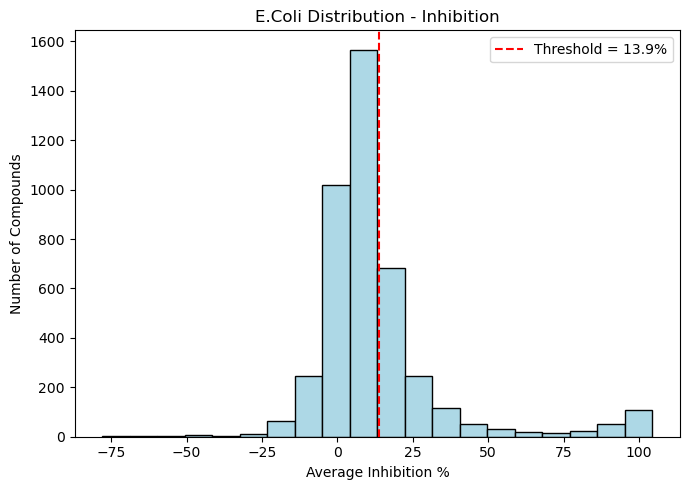

In [9]:
# Calculating the 70th percentile of INHIB_AVE to use as our cutoff
# Compounds above this value are active, below are inactive
threshold = master_df['INHIB_AVE'].quantile(0.7)

# Making the figure
fig, ax = plt.subplots(figsize=(7,5))

# Plotting the distribution of INHIB_AVE 
ax.hist(master_df['INHIB_AVE'], bins=20, edgecolor='black', color='lightblue')

# Adding a vertical line to show where the active/inactive cutoff is
ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.1f}%')

# Adding the title and labels
ax.set_title('E.Coli Distribution - Inhibition')
ax.set_xlabel('Average Inhibition %')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

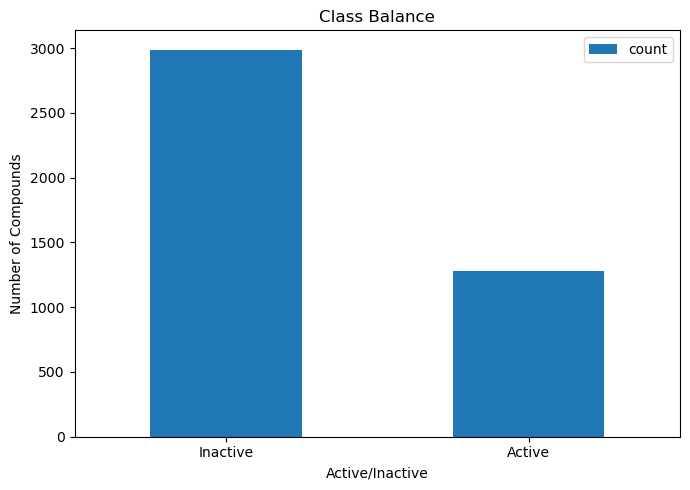

In [19]:
# Creating binary labels - 1 if compound is active (above threshold), 0 if inactive
ydummy_train = (master_df['INHIB_AVE'] > master_df['INHIB_AVE'].quantile(0.7)).astype(int)

# Making the figure
fig, ax = plt.subplots(figsize=(7,5))

# Plotting how many compounds fall into each class
ydummy_train.value_counts().plot(kind='bar', ax=ax)

# Labeling the bars and add title
ax.set_xticklabels(['Inactive', 'Active'], rotation=0)
ax.set_title('Class Balance')
ax.set_xlabel('Active/Inactive')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

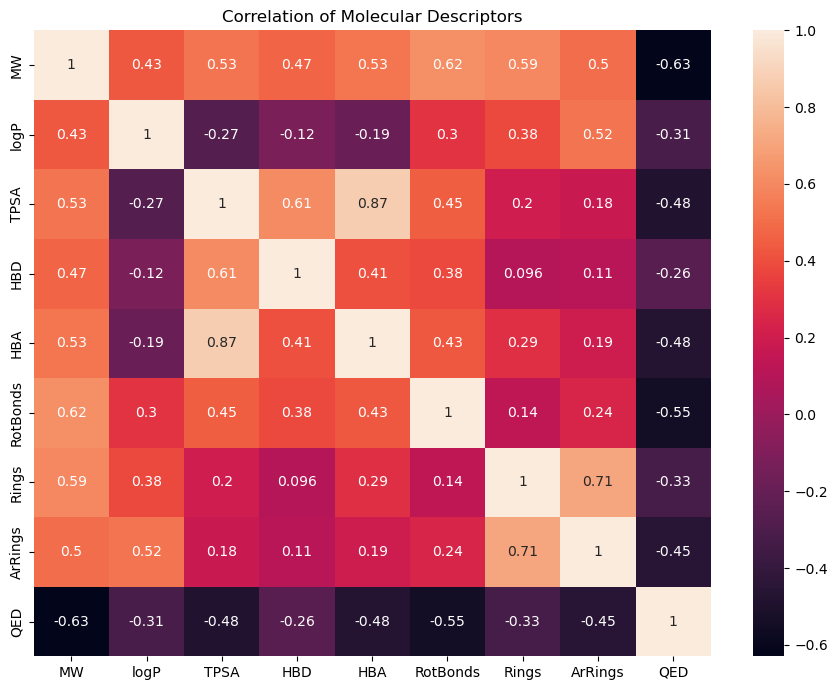

In [20]:
# Listing of the 9 molecular descriptors we computed from SMILES
DESCRIPTOR_COLUMNS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']

# Making the figure
fig, ax = plt.subplots(figsize=(9,7))


# Plotting the correlation between all 9 descriptors
sns.heatmap(master_df[DESCRIPTOR_COLUMNS].corr(), annot=True, ax=ax)

# Adfding title
ax.set_title('Correlation of Molecular Descriptors')

plt.tight_layout()
plt.show()

----------------------------
## Simple Logistic Regression Model

A Gaussian Mixture Model (GMM) was applied to the distribution of INHIB_AVE to identify potential latent subpopulations in antibacterial activity. The left panel shows the fitted mixture model overlaid on the empirical distribution, where two Gaussian components capture low and high inhibition groups, and a data-driven cutoff is defined at the midpoint between component means. The right panel shows the corresponding cluster assignments for each observation, illustrating how samples are probabilistically separated into two biologically meaningful groups. This approach provides a more interpretable and data-driven alternative to an arbitrary median split for defining inhibition classes.

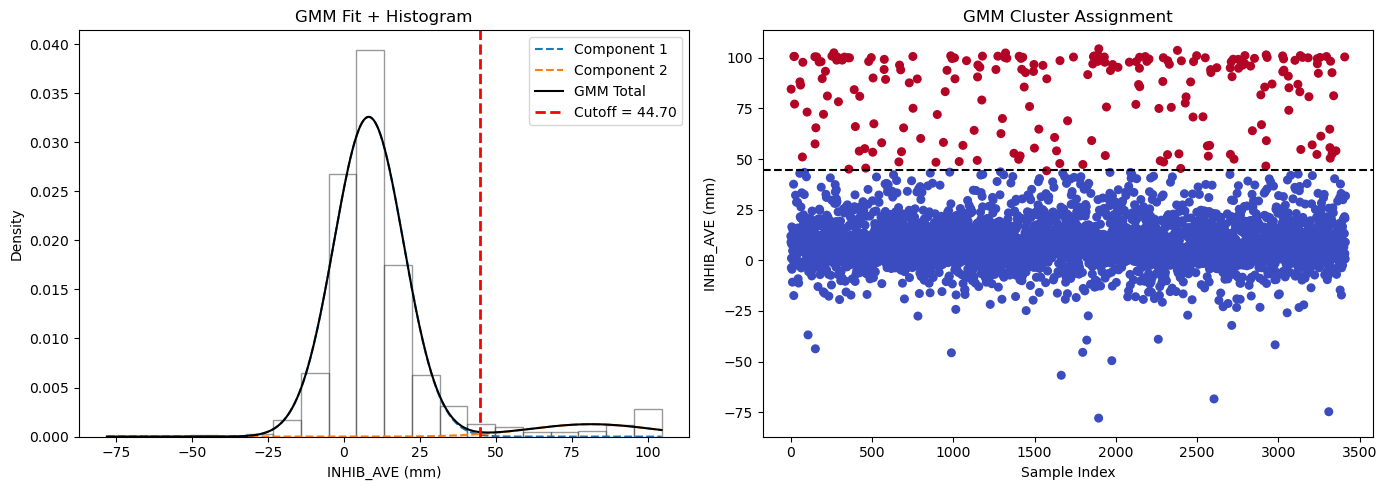

In [11]:
data = y_train.values.reshape(-1, 1)

# Fit GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data)

# Cutoff
means = gmm.means_.flatten()
threshold = np.mean(means)

# Smooth density curve
x = np.linspace(data.min(), data.max(), 500).reshape(-1, 1)
logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

responsibilities = gmm.predict_proba(x)
pdf_individual = responsibilities * pdf[:, np.newaxis]

# Cluster labels for each sample
labels = gmm.predict(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + GMM + cutoff
axes[0].hist(data, bins=20, density=True, alpha=0.4,
             color='white', edgecolor='black')

axes[0].plot(x, pdf_individual[:, 0], '--', label='Component 1')
axes[0].plot(x, pdf_individual[:, 1], '--', label='Component 2')
axes[0].plot(x, pdf, 'k-', label='GMM Total')

axes[0].axvline(threshold, color='red', linestyle='--',
                linewidth=2, label=f'Cutoff = {threshold:.2f}')

axes[0].set_title("GMM Fit + Histogram")
axes[0].set_xlabel("INHIB_AVE (mm)")
axes[0].set_ylabel("Density")
axes[0].legend()


# GMM clustering view

axes[1].scatter(range(len(data)), data, c=labels, cmap='coolwarm', s=30)

axes[1].axhline(threshold, color='black', linestyle='--')

axes[1].set_title("GMM Cluster Assignment")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("INHIB_AVE (mm)")

plt.tight_layout()
plt.show()

In [12]:
print("Means:", gmm.means_.flatten())
print("Variances:", gmm.covariances_.flatten())
print("Weights:", gmm.weights_.flatten())

Means: [ 8.1275686  81.26338313]
Variances: [131.00245564 421.11691684]
Weights: [0.93502847 0.06497153]


The Gaussian Mixture Model does not support a biologically meaningful bimodal structure in INHIB_AVE. One dominant distribution accounts for the majority of observations, while a second small component corresponds to extreme high-value outliers. Therefore, a data-driven threshold based on distribution quantiles is more appropriate than mixture-based clustering. A 70th percentile cutoff was selected to define high antibacterial activity, ensuring a balanced yet biologically meaningful classification of the strongest-performing compounds. This choice avoids sensitivity to extreme outliers observed in the distribution and provides sufficient class representation for stable model estimation.

0 = low / moderate inhibition (bottom 70%)
1 = high inhibition (top 30%)

------------------
## Simple Logistic Regression Model

In [13]:
threshold = y_train.quantile(0.7)

ydummy_train = (y_train > threshold).astype(int)
ydummy_test = (y_test > threshold).astype(int)

print("Threshold:", threshold)
print(ydummy_train.value_counts())

Threshold: 13.92
INHIB_AVE
0    2391
1    1023
Name: count, dtype: int64


0 = low / moderate inhibition (bottom 70%)
1 = high inhibition (top 30%)

In [14]:
X_train_glm = sm.add_constant(X_train_scaled)

glm_model = sm.GLM(ydummy_train, X_train_glm, family=sm.families.Binomial())
glm_results = glm_model.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     2376
Model Family:                Binomial   Df Model:                         1037
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -801.42
Date:                Mon, 04 May 2026   Deviance:                       1602.8
Time:                        23:34:45   Pearson chi2:                 1.80e+04
No. Iterations:                    24   Pseudo R-squ. (CS):             0.5284
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.0054    252.243     -0.016   

We now make prediction on test dataset

Accuracy: 0.6791569086651054
               Feature      Coef  Odds Ratio
morgan_939  morgan_939  3.408989   30.234673
DMAX_AVE      DMAX_AVE  2.577169   13.159827
morgan_659  morgan_659  1.922687    6.839313
ArRings        ArRings  1.437385    4.209673
morgan_231  morgan_231  1.335015    3.800054
...                ...       ...         ...
morgan_561  morgan_561 -1.995253    0.135979
morgan_838  morgan_838 -2.235978    0.106888
morgan_312  morgan_312 -2.257393    0.104623
morgan_685  morgan_685 -2.305338    0.099725
morgan_373  morgan_373 -2.982933    0.050644

[1037 rows x 3 columns]


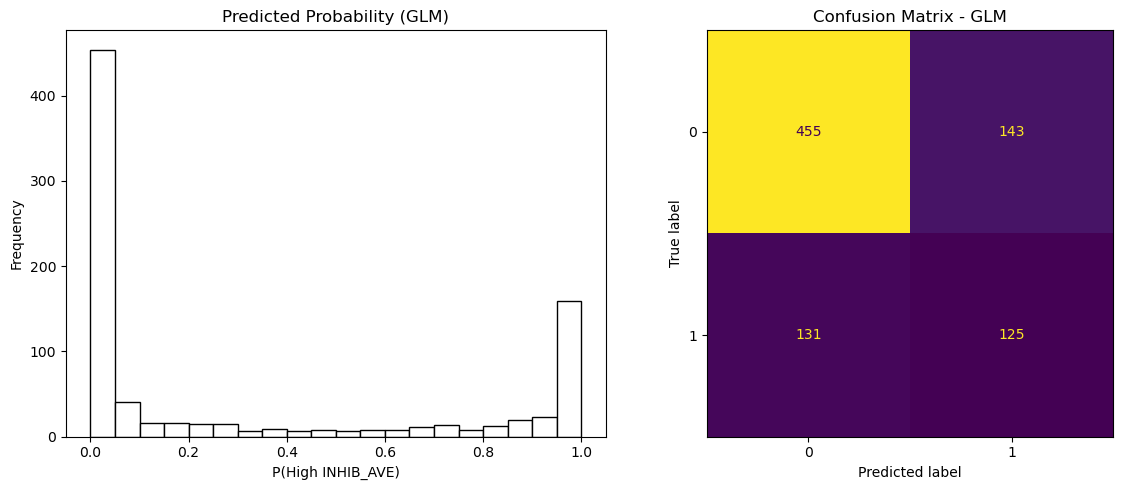

In [16]:
X_test_glm  = sm.add_constant(X_test_scaled, has_constant='add')

y_prob_log = glm_results.predict(X_test_glm)
y_pred_log = (y_prob_log > 0.5).astype(int)
print("Accuracy:", accuracy_score(ydummy_test, y_pred_log))

coefficients = pd.DataFrame({"Feature": X_train_scaled.columns, "Coef": glm_results.params[1:]})

coefficients["Odds Ratio"] = np.exp(coefficients["Coef"])

print(coefficients.sort_values("Odds Ratio", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Probability histogram
axes[0].hist(y_prob_log, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability (GLM)")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")


# Confusion matrix
cm = confusion_matrix(ydummy_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix - GLM")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import classification_report
print(classification_report(ydummy_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       598
           1       0.47      0.49      0.48       256

    accuracy                           0.68       854
   macro avg       0.62      0.62      0.62       854
weighted avg       0.68      0.68      0.68       854



The logistic regression (GLM with binomial family and logit link) achieved a test accuracy of 0.68 in classifying compounds as high or low inhibitory activity based on molecular descriptors and Morgan fingerprint features. Model performance was stronger for the low-activity class (precision 0.78, recall 0.76, F1-score 0.77) compared to the high-activity class (precision 0.47, recall 0.49, F1-score 0.48), indicating a bias toward correctly identifying inactive compounds. Feature analysis showed that several Morgan fingerprint bits and molecular descriptors had strong associations with activity, with positive predictors such as morgan_939, DMAX_AVE, and morgan_659 substantially increasing the odds of high activity, while other fingerprint bits showed strong negative associations. Overall, while the model captures meaningful structure–activity relationships, its moderate accuracy and weaker performance on the active class suggest limitations likely due to high-dimensional feature space and class imbalance effects.

-------------
## Logistic Regression with Feature Selection

Several predictors exhibited high p-values, suggesting redundancy and multicollinearity among molecular descriptors. While PCA could reduce dimensionality, it would compromise interpretability. Therefore, feature selection or more flexible nonlinear models may be more appropriate for capturing the structure–activity relationships present in the dataset.

In [18]:
# Copy coefficients from GLM results
coeffs = pd.DataFrame({
    "Feature": X_train_glm.columns,
    "Coef": glm_results.params
})

# Remove intercept
coeffs = coeffs[coeffs["Feature"] != "const"]

# Rank features by absolute coefficient magnitude
coeffs["abs_coef"] = coeffs["Coef"].abs()
top_features = coeffs.sort_values("abs_coef", ascending=False)

# Select top N features (e.g., 50)
selected_features = top_features["Feature"].head(50).tolist()

print("Selected features:", selected_features)

Selected features: ['morgan_939', 'morgan_373', 'DMAX_AVE', 'morgan_685', 'morgan_312', 'morgan_838', 'morgan_561', 'morgan_659', 'morgan_171', 'ArRings', 'morgan_87', 'HBA', 'morgan_231', 'morgan_112', 'morgan_693', 'logP', 'morgan_124', 'morgan_352', 'morgan_780', 'MIC_VALUE_uM', 'morgan_924', 'morgan_794', 'morgan_63', 'morgan_83', 'morgan_417', 'morgan_318', 'morgan_353', 'morgan_734', 'morgan_836', 'morgan_705', 'morgan_292', 'morgan_675', 'morgan_851', 'morgan_754', 'morgan_706', 'morgan_97', 'morgan_624', 'morgan_416', 'morgan_932', 'morgan_649', 'morgan_360', 'morgan_694', 'morgan_145', 'morgan_850', 'morgan_695', 'morgan_829', 'morgan_589', 'morgan_730', 'morgan_578', 'morgan_583']


In [23]:
# Reduce train/test sets
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

# Add constant for GLM
X_train_fs_glm = sm.add_constant(X_train_fs, has_constant="add")
X_test_fs_glm = sm.add_constant(X_test_fs, has_constant="add")

# Refit GLM on selected features
glm_fs = sm.GLM(
    ydummy_train,
    X_train_fs_glm,
    family=sm.families.Binomial()
).fit()

# Predictions
y_prob_fs = glm_fs.predict(X_test_fs_glm)
y_pred_fs = (y_prob_fs > 0.5).astype(int)

print(glm_fs.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     3363
Model Family:                Binomial   Df Model:                           50
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1653.0
Date:                Mon, 04 May 2026   Deviance:                       3306.1
Time:                        23:47:23   Pearson chi2:                 3.45e+03
No. Iterations:                    23   Pseudo R-squ. (CS):             0.2233
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.0793      0.285     -7.287   

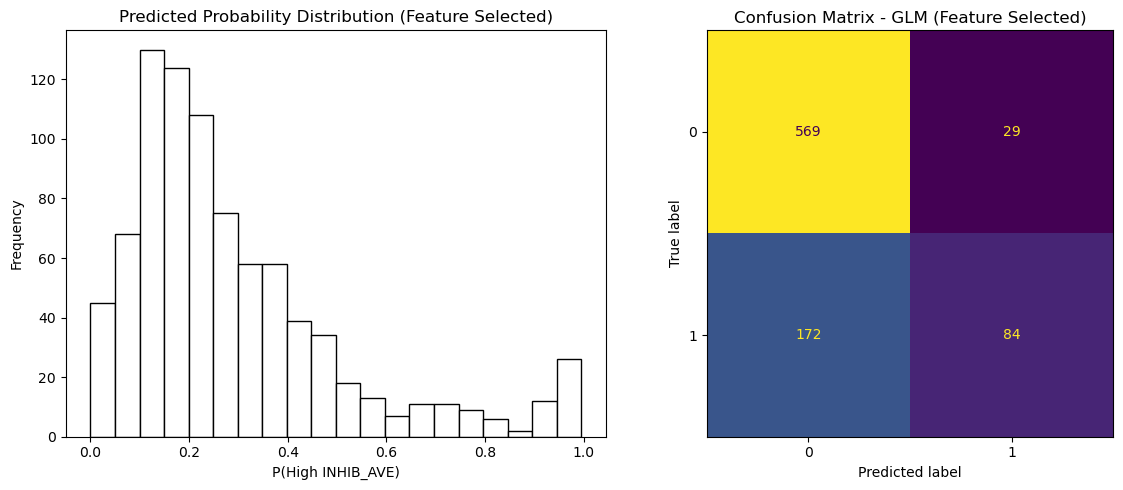

Accuracy (feature-selected model): 0.7646370023419203

Classification Report (Feature Selected GLM):

              precision    recall  f1-score   support

           0       0.77      0.95      0.85       598
           1       0.74      0.33      0.46       256

    accuracy                           0.76       854
   macro avg       0.76      0.64      0.65       854
weighted avg       0.76      0.76      0.73       854



In [24]:
# Figure setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(ydummy_test, y_pred_fs)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix - GLM (Feature Selected)")

# Probability distribution
axes[0].hist(y_prob_fs, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability Distribution (Feature Selected)")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Evaluation
print("Accuracy (feature-selected model):", accuracy_score(ydummy_test, y_pred_fs))

# Classification report
print("\nClassification Report (Feature Selected GLM):\n")
print(classification_report(ydummy_test, y_pred_fs))

After applying feature selection based on the magnitude of logistic regression coefficients, a reduced GLM model was trained using only the most informative molecular descriptors and Morgan fingerprint features. This feature-selected model achieved a higher overall test accuracy of 0.76 compared to the full model, indicating improved general predictive performance. The model showed strong performance in identifying inactive compounds (class 0), with high recall (0.95) and solid precision (0.77), meaning it correctly captured most low-activity molecules. However, performance on active compounds (class 1) remained limited, with lower recall (0.33) despite moderate precision (0.74), indicating that many active compounds were still misclassified as inactive. Overall, feature selection improved model efficiency and overall accuracy while maintaining strong specificity for inactive compounds, but sensitivity to active compounds remains a key limitation.

-------------------------
## Logistic Regression with Feature Selection and Elastic Net Regularization

In [30]:
alphas = [0.001, 0.01, 0.1, 1]
l1_weights = [0.0, 0.25, 0.5, 0.75, 1.0]

best_score = 0
best_params = None
best_model = None

for alpha in alphas:
    for l1 in l1_weights:
        
        model = sm.GLM(
            ydummy_train,
            X_train_fs_glm,
            family=sm.families.Binomial()
        )
        
        result = model.fit_regularized(
            method="elastic_net",
            alpha=alpha,
            L1_wt=l1,
            maxiter=2000
        )
        
        y_prob = result.predict(X_test_fs_glm)
        y_pred = (y_prob > 0.3).astype(int)
        
        score = accuracy_score(ydummy_test, y_pred)
        
        if score > best_score:
            best_score = score
            best_params = (alpha, l1)
            best_model = result

print("Best accuracy:", best_score)
print("Best alpha, L1_wt:", best_params)

Best accuracy: 0.711943793911007
Best alpha, L1_wt: (0.001, 1.0)


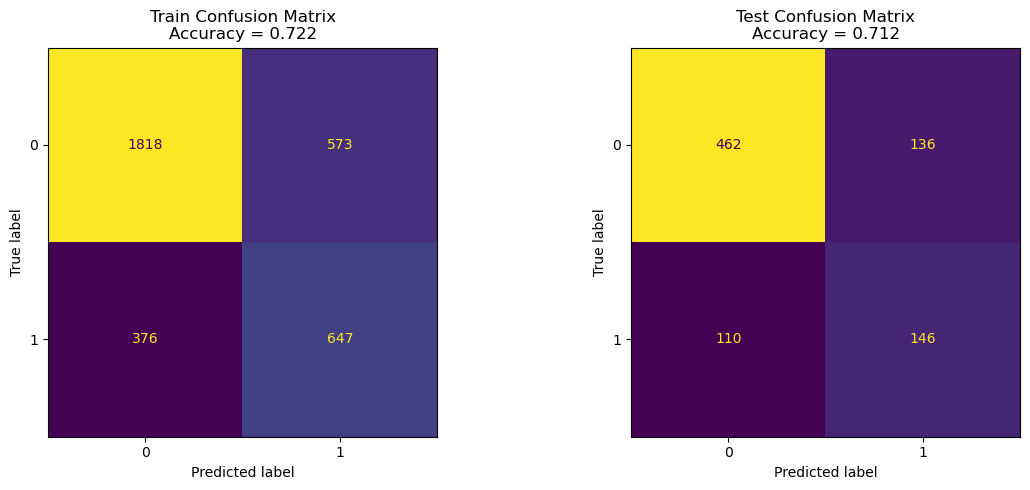

Train Accuracy: 0.7220269478617457
Test Accuracy: 0.711943793911007

Classification Report (Train):

              precision    recall  f1-score   support

           0       0.83      0.76      0.79      2391
           1       0.53      0.63      0.58      1023

    accuracy                           0.72      3414
   macro avg       0.68      0.70      0.68      3414
weighted avg       0.74      0.72      0.73      3414


Classification Report (Test):

              precision    recall  f1-score   support

           0       0.81      0.77      0.79       598
           1       0.52      0.57      0.54       256

    accuracy                           0.71       854
   macro avg       0.66      0.67      0.67       854
weighted avg       0.72      0.71      0.72       854



In [31]:
# Train predictions

y_prob_train = best_model.predict(X_train_fs_glm)
y_pred_train = (y_prob_train > 0.3).astype(int)

train_acc = accuracy_score(ydummy_train, y_pred_train)

cm_train = confusion_matrix(ydummy_train, y_pred_train)


# Test predictions

y_prob_test = best_model.predict(X_test_fs_glm)
y_pred_test = (y_prob_test > 0.3).astype(int)

test_acc = accuracy_score(ydummy_test, y_pred_test)

cm_test = confusion_matrix(ydummy_test, y_pred_test)

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train CM
ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Train Confusion Matrix\nAccuracy = {train_acc:.3f}")

# Test CM
ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Test Confusion Matrix\nAccuracy = {test_acc:.3f}")

plt.tight_layout()
plt.show()

# Accuracies
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Full report 
print("\nClassification Report (Train):\n")
print(classification_report(ydummy_train, y_pred_train))

print("\nClassification Report (Test):\n")
print(classification_report(ydummy_test, y_pred_test))

The elastic net regularized logistic regression model was optimized using a grid search over different values of α (regularization strength) and L1 weighting, applied to a reduced feature set derived from molecular descriptors and Morgan fingerprints. In addition, the classification threshold was lowered from the default 0.5 to 0.3 to better address the class imbalance present in the dataset, where inactive compounds (class 0) were more prevalent than active compounds (class 1). This adjustment made the model more sensitive to predicting the minority class as active, reducing the bias toward the majority class. The best-performing model achieved a test accuracy of approximately 0.71. While overall accuracy decreased compared to higher threshold settings, performance for the active class improved notably, with recall increasing to 0.57 and F1-score reaching 0.54, indicating a better balance between identifying true actives and controlling false positives. However, this improvement came with a reduction in precision (0.52), reflecting an expected trade-off due to the lower decision threshold. Overall, adjusting the threshold to 0.3 helped mitigate the effects of class imbalance and improved the model’s ability to identify biologically relevant active compounds, even at the cost of increased false positive predictions.


------------
## Simple Linear Regression

In [32]:
# build training dataframe
lin_df = X_train_scaled.copy()
lin_df["INHIB_AVE"] = y_train

# formula
equation = "INHIB_AVE ~ " + " + ".join(X_train_scaled.columns)

# fit model
lin_model = ols(equation, data=lin_df).fit()

# summary
print(lin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     6.046
Date:                Tue, 05 May 2026   Prob (F-statistic):          2.18e-286
Time:                        00:10:22   Log-Likelihood:                -13159.
No. Observations:                3414   AIC:                         2.839e+04
Df Residuals:                    2376   BIC:                         3.476e+04
Df Model:                        1037                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       12.8793      0.234     54.961   

In [33]:
# build test dataframe
lin_test_df = X_test_scaled.copy()

# predict
y_pred_lin = lin_model.predict(lin_test_df)

r2 = r2_score(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)
mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.4044188819346942
MSE: 289.30908644824717
MAE: 12.48844915130756
RMSE: 17.009088348534355


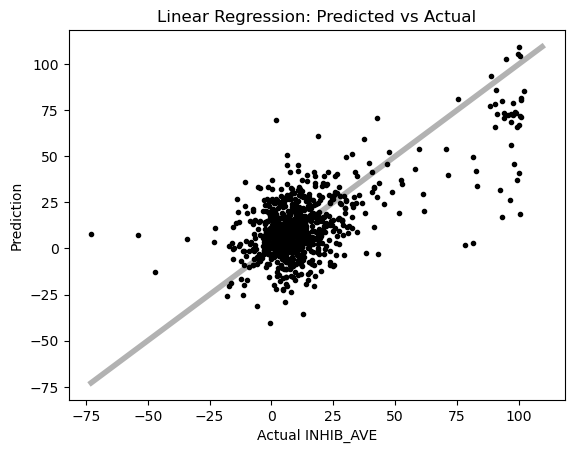

Mean Absolute Deviation: 12.48844915130756


In [34]:
higher = max(y_pred_lin.max(), y_test.max())
lower = min(y_pred_lin.min(), y_test.min())
plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

# scatter plot
plt.scatter(y_test, y_pred_lin, marker='.', color='black')

plt.ylabel('Prediction')
plt.xlabel('Actual INHIB_AVE')
plt.title('Linear Regression: Predicted vs Actual')

plt.show()

# mean absolute deviation
mean_dev = np.mean(np.abs(y_test - y_pred_lin))
print("Mean Absolute Deviation:", mean_dev)

------------------

## Simple Linear Regression with Feature Selection

In [36]:
# Build dataset
lin_df = X_train_scaled.copy()
lin_df["INHIB_AVE"] = y_train

# Full model formula
equation = "INHIB_AVE ~ " + " + ".join(X_train_scaled.columns)

# Fit full OLS model
lin_model = ols(equation, data=lin_df).fit()

# Extract p-values (excluding intercept)
pvalues = lin_model.pvalues.drop("Intercept")

# Select significant features (p < 0.05)
selected_features = pvalues[pvalues < 0.05].index.tolist()

print("Selected features (p < 0.05):")
print(selected_features)

Selected features (p < 0.05):
['DMAX_AVE', 'HBA', 'morgan_8', 'morgan_11', 'morgan_21', 'morgan_36', 'morgan_67', 'morgan_69', 'morgan_75', 'morgan_82', 'morgan_92', 'morgan_129', 'morgan_150', 'morgan_154', 'morgan_156', 'morgan_159', 'morgan_182', 'morgan_185', 'morgan_188', 'morgan_200', 'morgan_208', 'morgan_212', 'morgan_227', 'morgan_232', 'morgan_233', 'morgan_237', 'morgan_248', 'morgan_259', 'morgan_276', 'morgan_304', 'morgan_309', 'morgan_331', 'morgan_344', 'morgan_353', 'morgan_371', 'morgan_373', 'morgan_376', 'morgan_384', 'morgan_392', 'morgan_407', 'morgan_416', 'morgan_417', 'morgan_421', 'morgan_432', 'morgan_455', 'morgan_456', 'morgan_464', 'morgan_465', 'morgan_499', 'morgan_500', 'morgan_504', 'morgan_505', 'morgan_516', 'morgan_517', 'morgan_525', 'morgan_547', 'morgan_557', 'morgan_567', 'morgan_589', 'morgan_590', 'morgan_607', 'morgan_608', 'morgan_617', 'morgan_621', 'morgan_624', 'morgan_633', 'morgan_651', 'morgan_659', 'morgan_666', 'morgan_675', 'morgan_

In [37]:
# Reduce dataset to selected features
X_train_fs = X_train_scaled[selected_features]
X_test_fs = X_test_scaled[selected_features]

# Add target
lin_df_fs = X_train_fs.copy()
lin_df_fs["INHIB_AVE"] = y_train

# Build new formula
equation_fs = "INHIB_AVE ~ " + " + ".join(selected_features)

# Fit reduced model
lin_model_fs = ols(equation_fs, data=lin_df_fs).fit()

print(lin_model_fs.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     48.05
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        00:14:54   Log-Likelihood:                -13855.
No. Observations:                3414   AIC:                         2.791e+04
Df Residuals:                    3315   BIC:                         2.852e+04
Df Model:                          98                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      12.8793      0.243     52.945      

In [41]:
# prediction
y_pred_train = lin_model_fs.predict(X_train_fs)
y_pred_test = lin_model_fs.predict(X_test_fs)

# evaluation
print("TRAIN METRICS:")
print("R2:", r2_score(y_train, y_pred_train))
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))

print("\nTEST METRICS:")
print("R2:", r2_score(y_test, y_pred_test))
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

TRAIN METRICS:
R2: 0.5868424543413483
MSE: 196.16528533196265
MAE: 10.064522589067273
RMSE: 14.005901803595606

TEST METRICS:
R2: 0.5360280598880529
MSE: 225.3786999954719
MAE: 10.41946576187494
RMSE: 15.0126180260297


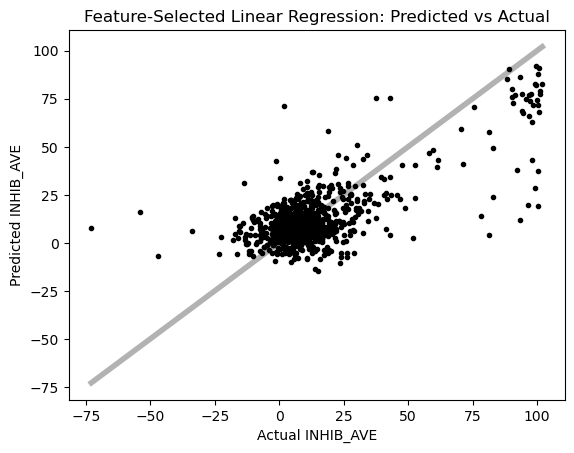

Mean Absolute Deviation: 10.41946576187494


In [42]:
higher = max(y_pred_test.max(), y_test.max())
lower = min(y_pred_test.min(), y_test.min())

plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

plt.scatter(y_test, y_pred_test, marker='.', color='black')

plt.ylabel('Predicted INHIB_AVE')
plt.xlabel('Actual INHIB_AVE')
plt.title('Feature-Selected Linear Regression: Predicted vs Actual')

plt.show()


# Mean Absolute Deviation

mean_dev = np.mean(np.abs(y_test - y_pred_test))
print("Mean Absolute Deviation:", mean_dev)

------------------
# Selected X_Train Window for Simple Linear Regression

In [57]:
mask_train = (y_train >= -20) & (y_train <= 30)
mask_test = (y_test >= -20) & (y_test <= 30)

X_train_f = X_train_scaled.loc[mask_train].reset_index(drop=True).copy()
y_train_f = y_train.loc[mask_train].reset_index(drop=True).copy()

X_test_f = X_test_scaled.loc[mask_test].reset_index(drop=True).copy()
y_test_f = y_test.loc[mask_test].reset_index(drop=True).copy()

X_train_fs_m = X_train_f[selected_features]
X_test_fs_m = X_test_f[selected_features]

train_fs_df = X_train_fs_m.copy()
train_fs_df["INHIB_AVE"] = y_train_f

equation_fs = "INHIB_AVE ~ " + " + ".join(selected_features)
ols_fs_m = ols(equation_fs, data=train_fs_df).fit()

print(ols_fs_m.summary())

                            OLS Regression Results                            
Dep. Variable:              INHIB_AVE   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     4.924
Date:                Tue, 05 May 2026   Prob (F-statistic):           3.38e-47
Time:                        00:39:37   Log-Likelihood:                -10728.
No. Observations:                3030   AIC:                         2.165e+04
Df Residuals:                    2931   BIC:                         2.225e+04
Df Model:                          98                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       8.0551      0.170     47.374      


TEST METRICS
R2: 0.05245545022954512
RMSE: 8.609243972331377
MAE: 6.709461255483722


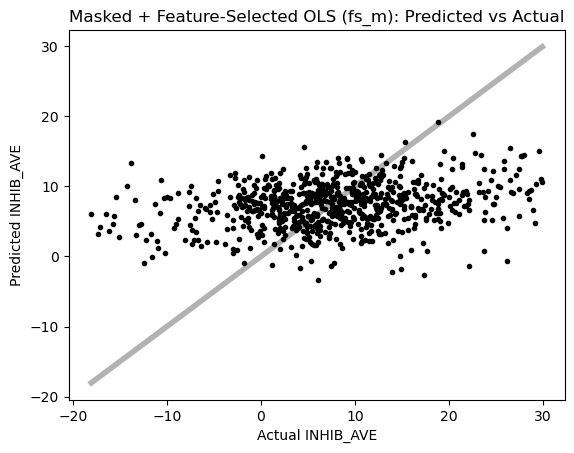

In [58]:
y_pred_test = ols_fs_m.predict(X_test_fs_m)

r2 = r2_score(y_test_f, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test_f, y_pred_test))
mae = mean_absolute_error(y_test_f, y_pred_test)

print("\nTEST METRICS")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

higher = max(y_pred_test.max(), y_test_f.max())
lower = min(y_pred_test.min(), y_test_f.min())

plt.plot([lower, higher], [lower, higher],
         color='black', alpha=0.3, linewidth=4)

plt.scatter(y_test_f, y_pred_test, marker='.', color='black')

plt.xlabel("Actual INHIB_AVE")
plt.ylabel("Predicted INHIB_AVE")
plt.title("Masked + Feature-Selected OLS (fs_m): Predicted vs Actual")

plt.show()

--------------------
## Error Weighted and Selected X_Train Window for Simple Linear Regression

In [43]:
mask_train = (y_train >= -20) & (y_train <= 30)
mask_test = (y_test >= -20) & (y_test <= 30)

X_train_f = X_train_scaled.loc[mask_train].copy()
y_train_f = y_train.loc[mask_train].copy()

X_test_f = X_test_scaled.loc[mask_test].copy()
y_test_f = y_test.loc[mask_test].copy()

In [44]:
# remove INHIB_STD and NASSAYSfrom feature
X_train_w = X_train_f.drop(columns=["INHIB_STD", "NASSAYS"])
X_test_w  = X_test_f.drop(columns=["INHIB_STD", "NASSAYS"])

In [45]:
# Fit WLS

alphas = [0.5, 1.0, 1.5, 2.0]
epsilons = [1e-3, 1e-2, 1e-1, 1]

results = []

X_train_w_const = sm.add_constant(X_train_w)
X_test_w_const = sm.add_constant(X_test_w)

for alpha in alphas:
    for eps in epsilons:
       # error weighing
       w = 1 / ((X_train_f["INHIB_STD"] + eps) ** alpha)

       # stabilize
       w = np.nan_to_num(w, nan=1.0, posinf=50, neginf=1.0)
       w = np.clip(w, 0, 50)
       w = w / np.mean(w)

       weights = w

       model = sm.WLS(y_train_f, X_train_w_const, weights=weights).fit()

       y_pred = model.predict(X_test_w_const)

       r2 = r2_score(y_test_f, y_pred)
       rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))

       results.append((alpha, eps, r2, rmse))

scored_results = []

for r in results:
    alpha, eps, r2, rmse = r

    score = r2 - 0.01 * rmse  # balance fit + error

    scored_results.append((alpha, eps, r2, rmse, score))

scored_results = sorted(scored_results, key=lambda x: x[4], reverse=True)

for r in scored_results[:5]:
    print("alpha:", r[0],
          "eps:", r[1],
          "R2:", r[2],
          "RMSE:", r[3],
          "Score:", r[4])

alpha: 1.0 eps: 0.001 R2: -267.09778805598694 RMSE: 144.81442082511776 Score: -268.5459322642381
alpha: 1.0 eps: 0.01 R2: -340.3747888067309 RMSE: 163.41086108312547 Score: -342.0088974175622
alpha: 1.5 eps: 0.001 R2: -428.18682739386594 RMSE: 183.22654326332753 Score: -430.0190928264992
alpha: 1.5 eps: 0.1 R2: -430.77338374509435 RMSE: 183.77783450415902 Score: -432.61116209013596
alpha: 1.0 eps: 0.1 R2: -432.0037245323545 RMSE: 184.03948625040445 Score: -433.8441193948586


The linear regression model performed poorly, with a strongly negative R² and high RMSE, indicating that it fails to capture meaningful structure–activity relationships in the dataset. This is likely due to the high-dimensional, sparse nature of Morgan fingerprint features and multicollinearity among predictors, which violate the assumptions of ordinary least squares regression.

-----------------------
## Model 3: Simple Artificial Neural Network (ANN)

As our third model we are using Multi-Layer Perceptron Classifier (MLPClassifier)
This is a simpple feedforward neural network with one hidden layer that learns non-linear relationships between molecular descriptors and antibacterial activity. 

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7959 - val_loss: 0.6183
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - loss: 0.3483 - val_loss: 0.6138
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - loss: 0.2358 - val_loss: 0.6524
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - loss: 0.1692 - val_loss: 0.7045
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 0.1277 - val_loss: 0.7478
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 0.1028 - val_loss: 0.7954
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.0830 - val_loss: 0.8380
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.0734 - val_loss: 0.8701
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: 0.0606 - val_loss: 0.9159
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0624 - val_loss: 0.9330
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.0531 - val_loss: 0.9585
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 85

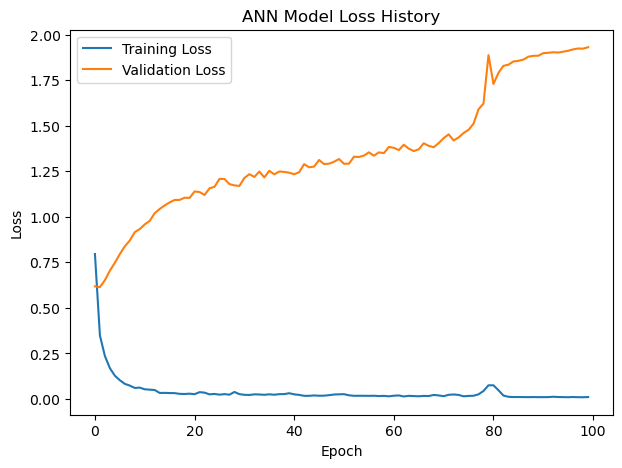

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy: 0.7002341920374707
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       598
           1       0.50      0.46      0.48       256

    accuracy                           0.70       854
   macro avg       0.64      0.63      0.64       854
weighted avg       0.69      0.70      0.70       854



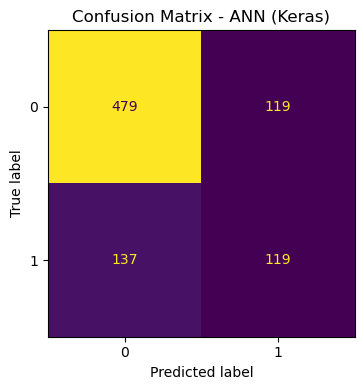

In [29]:
# Number of classes - we have 2 (active and inactive)
NClasses = 2

# One-hot encode the binary labels for Keras, using lines from keras notebook from lecture 15
Y_train_oh = keras.utils.to_categorical(ydummy_train, NClasses)
Y_test_oh = keras.utils.to_categorical(ydummy_test, NClasses)
# Number of neurons in the hidden layer
Nneuron = 64

# Building the ANN model using My_Keras_Model function pattern
def My_Keras_Model(Nneuron, NClasses):
    return keras.Sequential([
        # To help with the overfitting adding more dropout
        layers.Dense(Nneuron,  activation='relu'),
        layers.Dense(NClasses, activation='softmax')
    ])
keras_model = My_Keras_Model(Nneuron, NClasses)

# Compiling the model with adam optimizer and categorical_crossentropy loss
keras_model.compile(optimizer='adam', loss='categorical_crossentropy')

# Number of training epochs
Nepochs = 100

# Training the model on scaled training data with validation_split=0.2
history = keras_model.fit(X_train_scaled, Y_train_oh, epochs=Nepochs, validation_split=0.2)

# Plot the training and validation loss history
fig, ax = plt.subplots(figsize=(7,5))

# plot history['loss'] and history['val_loss']
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')

ax.set_title('ANN Model Loss History')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

# Make predictions on test data
P = keras_model.predict(X_test_scaled)

# Convert probabilities to class labels using np.argmax
y_pred_ann = np.argmax(P, axis=1)

# Printing the accuracy score
print("Accuracy:", accuracy_score(ydummy_test, y_pred_ann))

# Printing the classification report
print(classification_report(ydummy_test, y_pred_ann))

# Ploting the confusion matrix
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(ydummy_test, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - ANN (Keras)')
plt.tight_layout()
plt.show()

Attempted to reduce overfitting by applying PCA and Dropout layers, however the validation loss continued to diverge from training loss regardless of the approach. This suggests the E. coli inhibition dataset may not contain sufficient signal for a neural network to generalize well, which is consistent with Markus's observation that this is fundamentally a noisy regression problem. The final ANN model achieved 72% accuracy.

## Clustering Analysis
Applying K-Means clustering to explore 
whether active and inactive compounds naturally separate in the feature space.

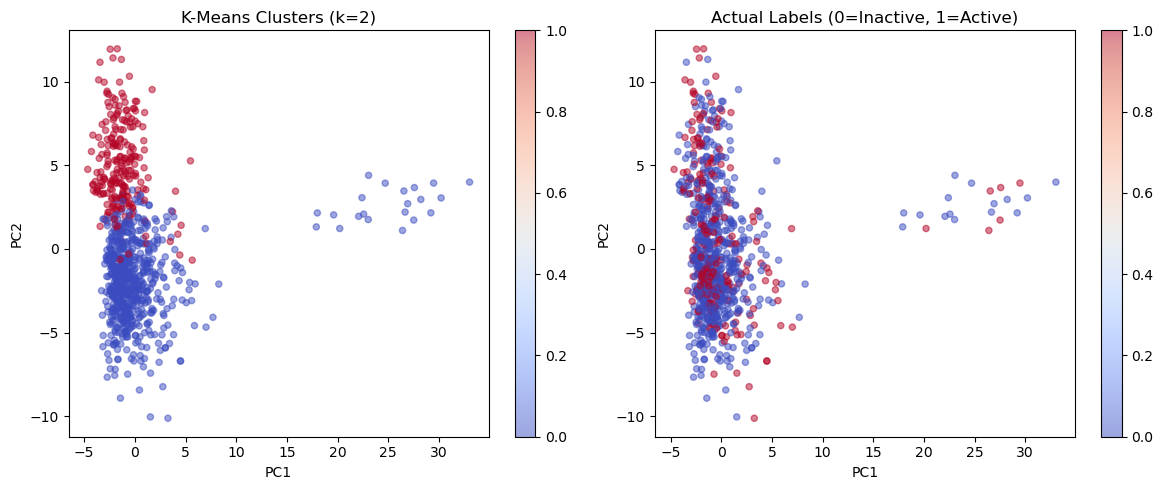

Cluster counts: 0    623
1    231
Name: count, dtype: int64


In [30]:
# Create KMeans model with 2 clusters since we have 2 classes (active and inactive)
# Added n_init=10 and max_iter=300 to improve clustering. Initial run with defaults resulted in a 853:1 split which was not meaningful
kmeans = KMeans(n_clusters=2, random_state=28, n_init=10, max_iter=300)

# Fit the model on the scaled training data
kmeans.fit(X_train_scaled)

# Get cluster labels for the test data
cluster_labels = kmeans.predict(X_test_scaled)

# Reduce to 2D using PCA so we can visualize the clusters
pca_vis = PCA(n_components=2)
X_2d = pca_vis.fit_transform(X_test_scaled)

# Plotting the clusters vs actual labels side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - color points by cluster label
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.5, s=20)
axes[0].set_title('K-Means Clusters (k=2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# Plotting the 2 color points by actual active/inactive labels
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=ydummy_test, cmap='coolwarm', alpha=0.5, s=20)
axes[1].set_title('Actual Labels (0=Inactive, 1=Active)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

# Print how many compounds fell into each cluster
print("Cluster counts:", pd.Series(cluster_labels).value_counts())

Running K-Means clustering with k=2 to see if the compounds would naturally split into active and inactive groups. Cluster 0 had 623 compounds and Cluster 1 had 231 compounds which is pretty close to our 70/30 class split. When we compare the clusters to our actual labels though, they don't line up perfectly the molecular descriptors alone aren't enough to cleanly separate active from inactive 
compounds. This makes sense given that our models also struggled with recall on the active class.

## UMAP

We use UMAP (Uniform Manifold Approximation and Projection) to visualize our high dimensional data in 2D. This helps us see if active and inactive compounds naturally separate in the feature space. 

/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


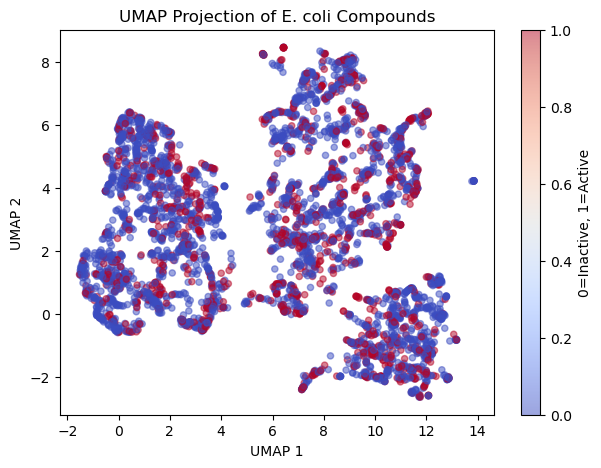

In [31]:
# Use only the original molecular descriptors for UMAP visualization
DESCRIPTOR_COLUMNS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']

# Scale just these columns
scaler_umap = StandardScaler()
X_umap_features = scaler_umap.fit_transform(master_df[DESCRIPTOR_COLUMNS])

# Create UMAP reducer
reducer = umap.UMAP(n_components=2, random_state=28)

# Fit and transform
X_umap = reducer.fit_transform(X_umap_features)

# Get labels for all data
y_all = (master_df['INHIB_AVE'] > master_df['INHIB_AVE'].quantile(0.7)).astype(int)

# Plot
fig, ax = plt.subplots(figsize=(7,5))
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=y_all, cmap='coolwarm', alpha=0.5, s=20)
ax.set_title('UMAP Projection of E. coli Compounds')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=ax, label='0=Inactive, 1=Active')
plt.show()

Looking at the UMAP projection, most compounds are clumped together in one big dense cluster with active and inactive compounds all mixed in together. There is no real separation between the two classes which makes sense given that our models had a hard time identifying active compounds too. 

---------------
## Clustering Visualization (90% Quantile)

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


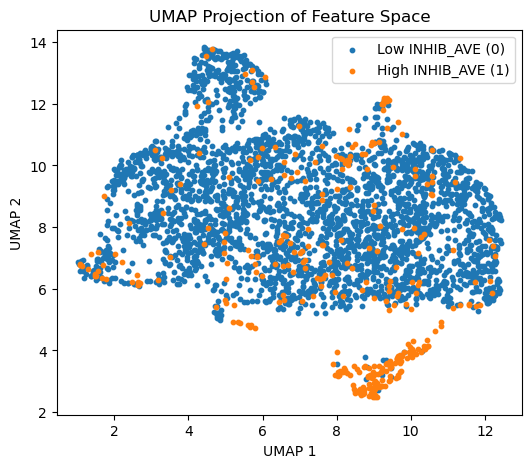

In [ ]:
threshold = y_train.quantile(0.9)
y_umap = (y_train > threshold).astype(int)

umap_data = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42).fit_transform(X_train_scaled)

plt.figure(figsize=(6, 5))

# class 0
plt.scatter(
    umap_data[y_umap == 0, 0],
    umap_data[y_umap == 0, 1],
    s=10,
    label="Low INHIB_AVE (0)"
)

# class 1
plt.scatter(
    umap_data[y_umap == 1, 0],
    umap_data[y_umap == 1, 1],
    s=10,
    label="High INHIB_AVE (1)"
)

plt.title("UMAP Projection of Feature Space")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend()
plt.show()

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


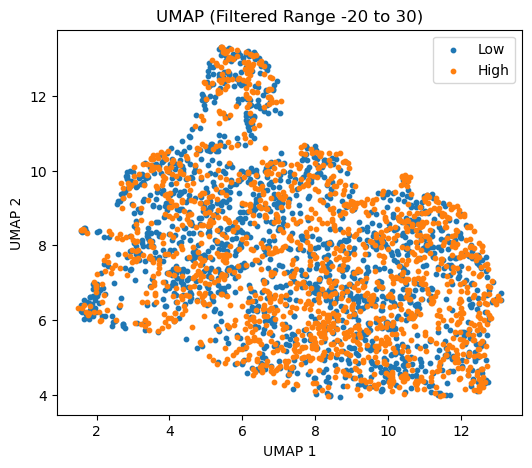

In [ ]:
mask = (y_train >= -20) & (y_train <= 30)

X_umap = X_train_scaled.loc[mask].copy()
y_umap = y_train.loc[mask].copy()

umap_data = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
).fit_transform(X_umap)

labels = (y_umap > y_umap.median()).astype(int)

plt.figure(figsize=(6, 5))

plt.scatter(
    umap_data[labels == 0, 0],
    umap_data[labels == 0, 1],
    s=10,
    label="Low"
)

plt.scatter(
    umap_data[labels == 1, 0],
    umap_data[labels == 1, 1],
    s=10,
    label="High"
)

plt.title("UMAP (Filtered Range -20 to 30)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

---------

## K-Means Clustering with PCA

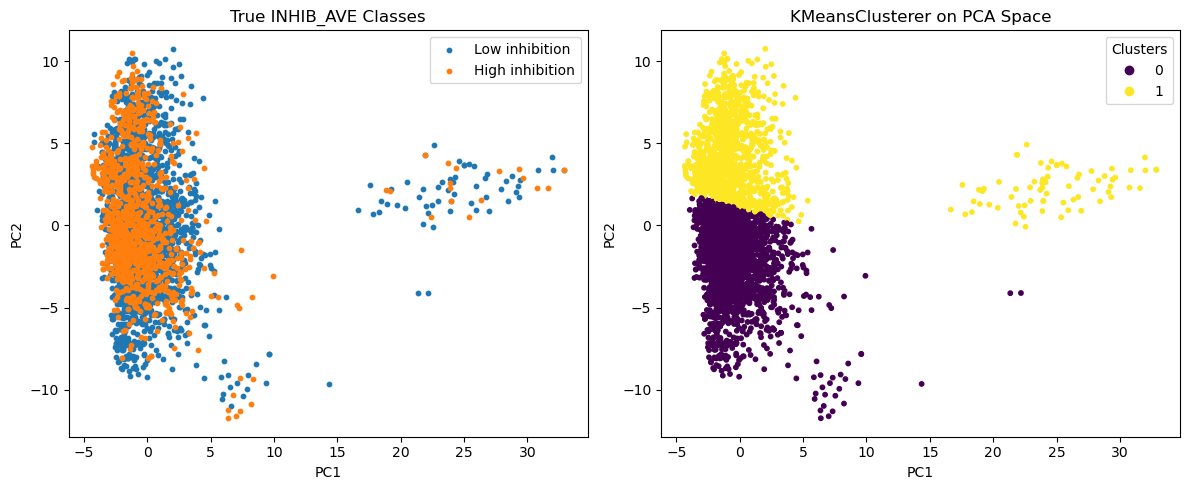

In [47]:
# PCA
X_np = X_train_scaled.to_numpy()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

# binary inhibition labels
threshold = y_train.quantile(0.7)
y_train_class = (y_train > threshold).astype(int)

# KMeansClusterer (NLTK)
dist = distance_metric(type_metric.EUCLIDEAN)

km_model = KMeansClusterer(
    2,
    distance=dist,
    repeats=25,
    avoid_empty_clusters=True
)

kmeans_labels = km_model.cluster(X_pca, assign_clusters=True)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- LEFT: true classes ---
axes[0].scatter(
    X_pca[y_train_class == 0, 0],
    X_pca[y_train_class == 0, 1],
    s=10,
    label="Low inhibition"
)

axes[0].scatter(
    X_pca[y_train_class == 1, 0],
    X_pca[y_train_class == 1, 1],
    s=10,
    label="High inhibition"
)

axes[0].set_title("True INHIB_AVE Classes")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# --- RIGHT: KMeansClusterer clusters ---
scatter = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=10
)

axes[1].set_title("KMeansClusterer on PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

axes[1].legend(*scatter.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

In [50]:
score = silhouette_score(X_pca, kmeans_labels)

print("Silhouette Score (KMeansClusterer on PCA):", score)

Silhouette Score (KMeansClusterer on PCA): 0.45064471094733


 ## GMM–UMAP plot

To further investigate whether the bimodal structure identified in the target variable (INHIB_AVE) is reflected in the feature space, a Gaussian Mixture Model (GMM) was fitted to INHIB_AVE to identify potential latent subpopulations. The resulting cluster assignments were then projected onto a UMAP embedding of the scaled feature set. This allows us to assess whether the distribution-based clusters correspond to any separable structure in the high-dimensional feature space.

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


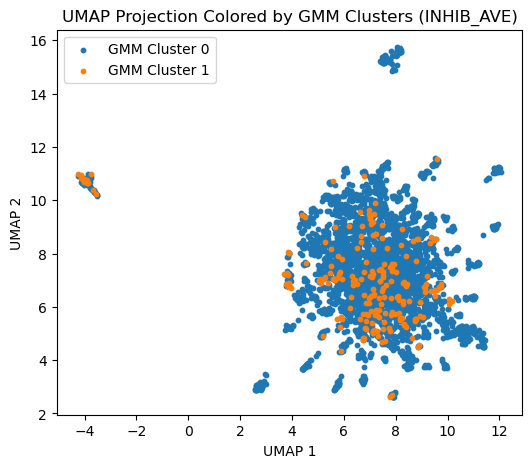

In [51]:
# UMAP on feature space
umap_data = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    random_state=42
).fit_transform(X_train_scaled)

# GMM labels (from y_train)
labels = gmm.predict(y_train.values.reshape(-1, 1))

plt.figure(figsize=(6, 5))

plt.scatter(
    umap_data[labels == 0, 0],
    umap_data[labels == 0, 1],
    s=10,
    label="GMM Cluster 0"
)

plt.scatter(
    umap_data[labels == 1, 0],
    umap_data[labels == 1, 1],
    s=10,
    label="GMM Cluster 1"
)

plt.title("UMAP Projection Colored by GMM Clusters (INHIB_AVE)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()

---------------
## GMM with PCA

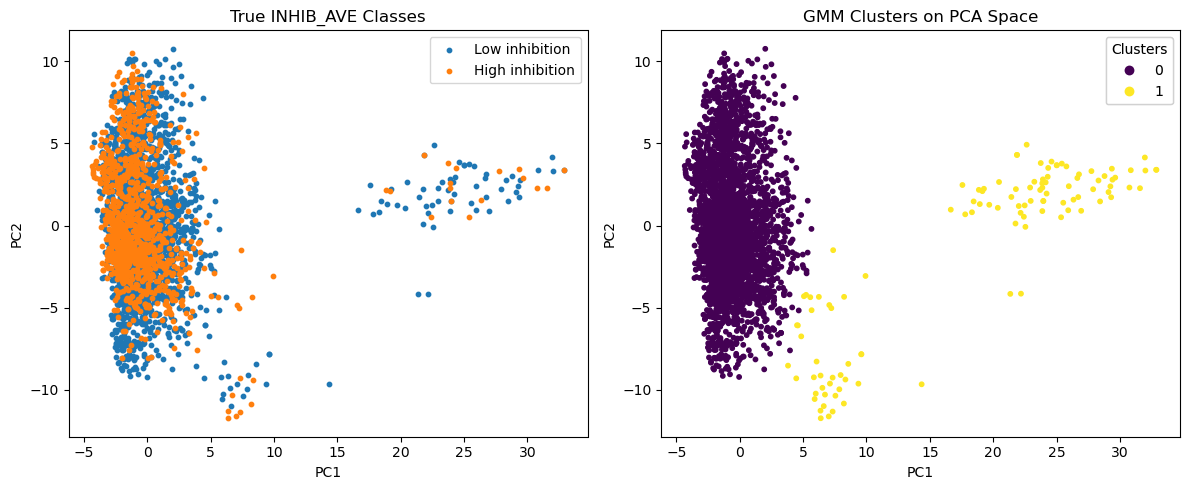

In [52]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# binary labels
threshold = y_train.quantile(0.7)
y_train_class = (y_train > threshold).astype(int)

# GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- LEFT: true high/low inhibition ---
axes[0].scatter(
    X_pca[y_train_class == 0, 0],
    X_pca[y_train_class == 0, 1],
    s=10,
    label="Low inhibition"
)

axes[0].scatter(
    X_pca[y_train_class == 1, 0],
    X_pca[y_train_class == 1, 1],
    s=10,
    label="High inhibition"
)

axes[0].set_title("True INHIB_AVE Classes")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# --- RIGHT: GMM clusters ---
scatter = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels,
    cmap='viridis',
    s=10
)

axes[1].set_title("GMM Clusters on PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# legend for GMM
legend1 = axes[1].legend(*scatter.legend_elements(),
                         title="Clusters")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

In [54]:
score = silhouette_score(X_pca, gmm_labels)

print("Silhouette Score (GMM on PCA):", score)

Silhouette Score (GMM on PCA): 0.7469111324656874
